# Multihazard Risk Screening of Rural Schools, Part 4: Scenario Studies

The four deployed models emulate the specialist at negligible cost, which
unlocks a use the original field campaign could not afford: scoring large
hypothetical portfolios and measuring the effect of retrofit policies before
committing budget.

Configurations are drawn at random under realism constraints distilled from
the field campaign (load bearing wall systems stay under three stories,
earthen buildings are single story with a regular plan, informally mixed
systems never show good quality). Every configuration is then rated by the
trained models. No confidential scoring logic is involved: the labels come
from the published pipelines.

In [1]:
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src" / "schoolrisk").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
import pandas as pd

from schoolrisk.config import HAZARDS, RISK_LEVELS
from schoolrisk.modeling import load_model
from schoolrisk.plots import apply_style, risk_distribution_figure, save_figure
from schoolrisk.simulate import (
    apply_intervention,
    generate_buildings,
    label_with_model,
    risk_migration,
)

apply_style()
models = {hazard: load_model(hazard) for hazard in HAZARDS}

## 1. A synthetic portfolio of one thousand buildings per hazard

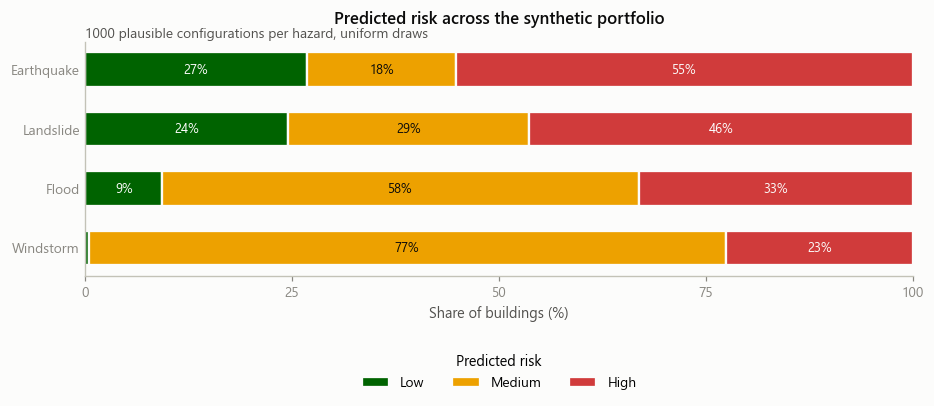

In [3]:
N = 1000
portfolios = {}
for hazard in HAZARDS:
    buildings = generate_buildings(hazard, n=N, seed=7)
    portfolios[hazard] = label_with_model(buildings, models[hazard])

distributions = {
    hazard: portfolios[hazard]["risk_level"].value_counts()
    for hazard in HAZARDS
}
fig = risk_distribution_figure(
    distributions,
    "Predicted risk across the synthetic portfolio",
    subtitle=f"{N} plausible configurations per hazard, uniform draws",
)
_ = save_figure(fig, "scenario_distribution")

Uniform draws are not a census, they are a stress view of the configuration
space. Read the shares as **how much of the plausible configuration space is
dangerous**, not as the condition of any real district. Flood stands out
immediately: most plausible configurations rate Medium or High, because a
single missing barrier weighs so heavily.

## 2. What if campaigns: one targeted retrofit per hazard

Each hazard gets the intervention its SHAP profile points to. The retrofit is
applied to every building in the portfolio that does not already have it and
the fleet is rescored.

In [4]:
INTERVENTIONS = {
    "earthquake": {"ring_beam": "Yes", "wall_connections": "Yes"},
    "landslide": {"slope_retention": "Effective", "retention_maintenance": "Good"},
    "flood": {"flood_barrier": "Yes"},
    "windstorm": {
        "roof_covering": "Clay tiles",
        "roof_condition": "Good",
        "roof_anchorage": "Good",
    },
}

results = []
after_portfolios = {}
for hazard, changes in INTERVENTIONS.items():
    before = portfolios[hazard]
    after = apply_intervention(before.drop(columns="risk_level"), changes)
    after = label_with_model(after, models[hazard])
    after_portfolios[hazard] = after
    results.append(
        {
            "Hazard": HAZARDS[hazard].display,
            "Retrofit": ", ".join(
                f"{HAZARDS[hazard].display_name(k)} to {v}"
                for k, v in changes.items()
            ),
            "High before": (before["risk_level"] == "High").mean(),
            "High after": (after["risk_level"] == "High").mean(),
            "Low before": (before["risk_level"] == "Low").mean(),
            "Low after": (after["risk_level"] == "Low").mean(),
        }
    )
effect = pd.DataFrame(results)
effect.style.format({c: "{:.1%}" for c in effect.columns[2:]}).hide(axis="index")

Hazard,Retrofit,High before,High after,Low before,Low after
Earthquake,"Ring beam at wall tops to Yes, Wall to wall connections to Yes",55.2%,21.9%,26.8%,52.5%
Landslide,"Slope retention system to Effective, Retention system maintenance to Good",46.4%,39.8%,24.5%,34.3%
Flood,Flood protection barrier to Yes,33.1%,0.0%,9.3%,14.7%
Windstorm,"Roof covering to Clay tiles, Roof condition to Good, Roof to wall anchorage to Good",22.6%,0.3%,0.4%,6.4%


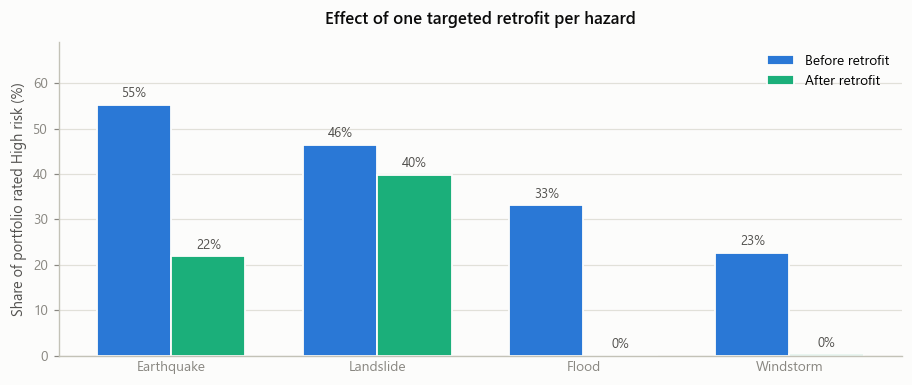

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from schoolrisk.plots import INK_SOFT, SURFACE

fig, ax = plt.subplots(figsize=(8.4, 3.6))
x = np.arange(len(effect))
width = 0.36
bars_before = ax.bar(x - width / 2, effect["High before"] * 100, width,
                     label="Before retrofit", color="#2a78d6",
                     edgecolor=SURFACE, linewidth=1.2)
bars_after = ax.bar(x + width / 2, effect["High after"] * 100, width,
                    label="After retrofit", color="#1baf7a",
                    edgecolor=SURFACE, linewidth=1.2)
for bars in (bars_before, bars_after):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f"{bar.get_height():.0f}%", ha="center", va="bottom",
                fontsize=8.6, color=INK_SOFT)
ax.set_xticks(x, effect["Hazard"])
ax.set_ylabel("Share of portfolio rated High risk (%)")
ax.set_ylim(0, max(effect["High before"].max() * 100 * 1.25, 10))
ax.tick_params(axis="x", length=0)
ax.yaxis.grid(True)
ax.set_axisbelow(True)
ax.legend()
ax.set_title("Effect of one targeted retrofit per hazard", pad=12)
fig.tight_layout()
_ = save_figure(fig, "retrofit_effect")

## 3. Where do the buildings go

The migration matrix details the flood campaign: rows are ratings before the
barrier, columns after. Mass moves off the High row toward Medium and Low,
and no building gets worse, a coherence check on the model as much as a
policy result.

In [6]:
migration = risk_migration(
    portfolios["flood"]["risk_level"], after_portfolios["flood"]["risk_level"]
)
migration

After,Low,Medium,High
Before,,,
Low,93,0,0
Medium,26,550,0
High,28,303,0


## Closing

Three things make this portfolio piece work as engineering, not only as
machine learning.

* The models reproduce a specialist's judgment with cross validated macro F1
  between 0.92 and 0.97 for every hazard, confirmed by the holdout audits.
* Their decision signal matches the physics of each failure mechanism, which
  notebook three verifies attribute by attribute.
* Deployed as emulators, they turn a manual rating protocol into an
  instrument for portfolio screening and retrofit planning, as this notebook
  demonstrates end to end.